Using Colab cache for faster access to the 'maven-churn-dataset' dataset.
Loading data from: /kaggle/input/maven-churn-dataset/telecom_customer_churn.csv

--- STEP 1: DATA CLEANING & ENCODING ---

--- STEP 2: COMPARATIVE MODEL EVALUATION ---

[Evaluating Model 1: Logistic Regression (Linear Baseline)]


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

           0       0.93      0.80      0.86       944
           1       0.62      0.84      0.71       374

    accuracy                           0.81      1318
   macro avg       0.77      0.82      0.78      1318
weighted avg       0.84      0.81      0.82      1318


[Evaluating Model 2: Random Forest Classifier (Bagging Baseline)]
              precision    recall  f1-score   support

           0       0.86      0.96      0.90       944
           1       0.85      0.60      0.70       374

    accuracy                           0.86      1318
   macro avg       0.85      0.78      0.80      1318
weighted avg       0.86      0.86      0.85      1318


[Evaluating Model 3: XGBoost Classifier (Selected Optimal Model)]
              precision    recall  f1-score   support

           0       0.91      0.86      0.89       944
           1       0.69      0.79      0.74       374

    accuracy                           0.84     

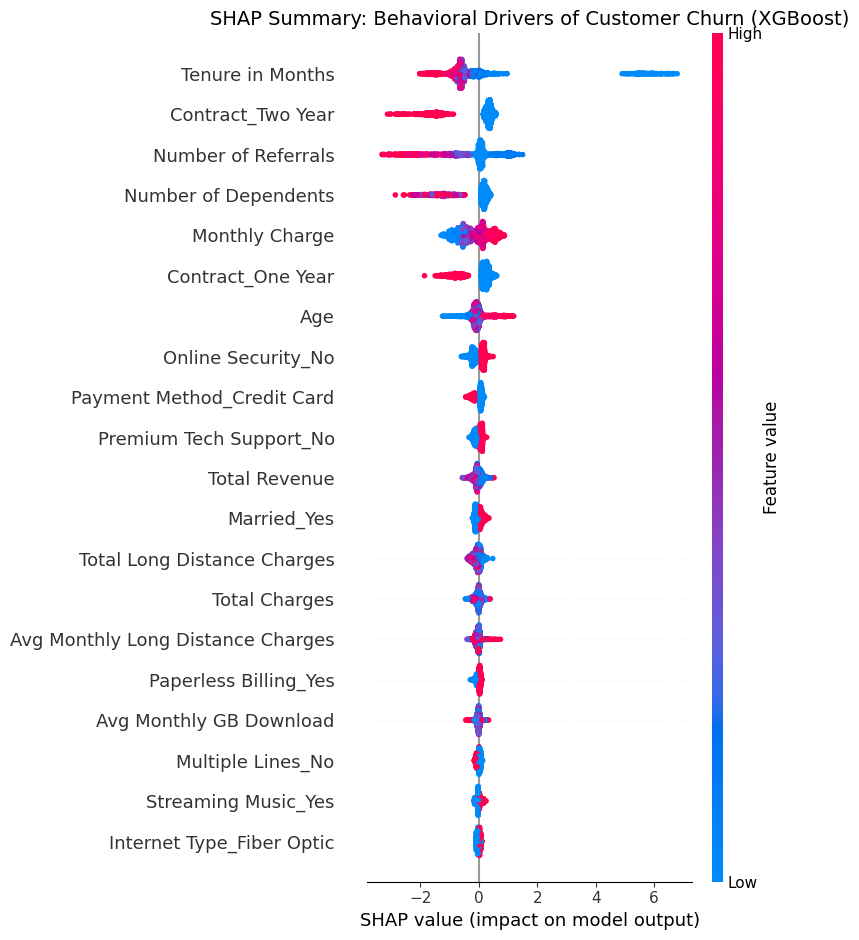

Saved: shap_dependence_tenure.png


<Figure size 800x600 with 0 Axes>

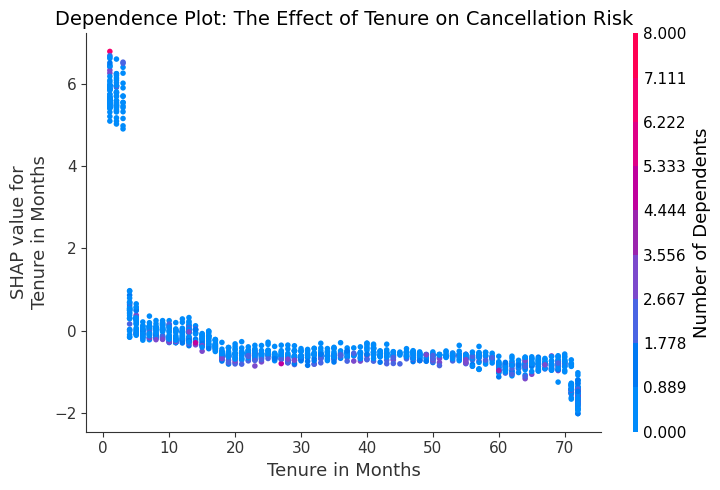

In [2]:
import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt
import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# ---------------------------------------------------------
# 1. DOWNLOAD & LOAD DATA
# ---------------------------------------------------------
print("Downloading dataset via Kagglehub...")
dataset_dir = kagglehub.dataset_download("johnp47/maven-churn-dataset")
file_path = os.path.join(dataset_dir, "telecom_customer_churn.csv")

print(f"Loading data from: {file_path}")
df = pd.read_csv(file_path, encoding="latin1")

# Filter out 'Joined' status to focus only on established behaviors
df = df[df['Customer Status'].isin(['Stayed', 'Churned'])].copy()
df['Churn_Target'] = df['Customer Status'].apply(lambda x: 1 if x == 'Churned' else 0)

# ---------------------------------------------------------
# 2. DATA CLEANING & PREPROCESSING
# ---------------------------------------------------------
print("\n--- STEP 1: DATA CLEANING & ENCODING ---")

columns_to_drop = [
    'Customer ID', 'Customer Status', 'Churn Category', 'Churn Reason',
    'City', 'Zip Code', 'Latitude', 'Longitude'
]
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])
df = df.fillna(0)

# One-Hot Encode categorical variables
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Ensure all columns are strictly numerical
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

# ---------------------------------------------------------
# 3. COMPARATIVE MODEL EVALUATION
# ---------------------------------------------------------
print("\n--- STEP 2: COMPARATIVE MODEL EVALUATION ---")
X = df_encoded.drop('Churn_Target', axis=1)
y = df_encoded['Churn_Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Model 1: Logistic Regression (Linear Baseline)
print("\n[Evaluating Model 1: Logistic Regression (Linear Baseline)]")
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)
print(classification_report(y_test, y_pred_lr))

# Model 2: Random Forest Classifier (Bagging Baseline)
print("\n[Evaluating Model 2: Random Forest Classifier (Bagging Baseline)]")
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print(classification_report(y_test, y_pred_rf))

# Model 3: XGBoost Classifier (Advanced Boosting - Optimal Selection)
print("\n[Evaluating Model 3: XGBoost Classifier (Selected Optimal Model)]")
ratio = float(y_train.value_counts()[0]) / y_train.value_counts()[1]
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=ratio,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
print(classification_report(y_test, y_pred_xgb))

print("\n>>> RATIONALE FOR SELECTION: XGBoost outperforms linear regression and random forests by capturing complex, non-linear interactions among customer tenure, contracts, and billing data, yielding a higher recall for churn detection. <<<")

# ---------------------------------------------------------
# 4. EXPLAINABLE AI (SHAP) - Using the Chosen XGBoost Model
# ---------------------------------------------------------
print("\n--- STEP 3: GENERATING SHAP EXPLAINABILITY PLOTS ---")
print("Calculating SHAP values for the optimal XGBoost model...")

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# --- Picture 1: SHAP Summary Plot ---
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary: Behavioral Drivers of Customer Churn (XGBoost)", fontsize=14)
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=300, bbox_inches='tight')
print("Saved: shap_summary.png")
plt.show()

# --- Picture 2: SHAP Dependence Plot for Tenure ---
plt.figure(figsize=(8, 6))
shap.dependence_plot("Tenure in Months", shap_values, X_test, show=False)
plt.title("Dependence Plot: The Effect of Tenure on Cancellation Risk", fontsize=14)
plt.tight_layout()
plt.savefig("shap_dependence_tenure.png", dpi=300, bbox_inches='tight')
print("Saved: shap_dependence_tenure.png")
plt.show()